In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.transform import resize


In [2]:

image = data.camera()

image = resize(image, (256, 256))

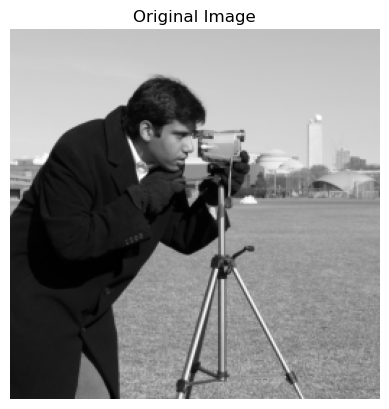

In [3]:
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [4]:
M, N = image.shape

print(M)
print(N)

256
256


In [5]:
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

In [6]:
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

In [7]:
F = np.fft.fft2(image)

In [8]:
F_lap = F * laplacian_filter

In [9]:
laplacian_image = np.fft.ifft2(F_lap).real

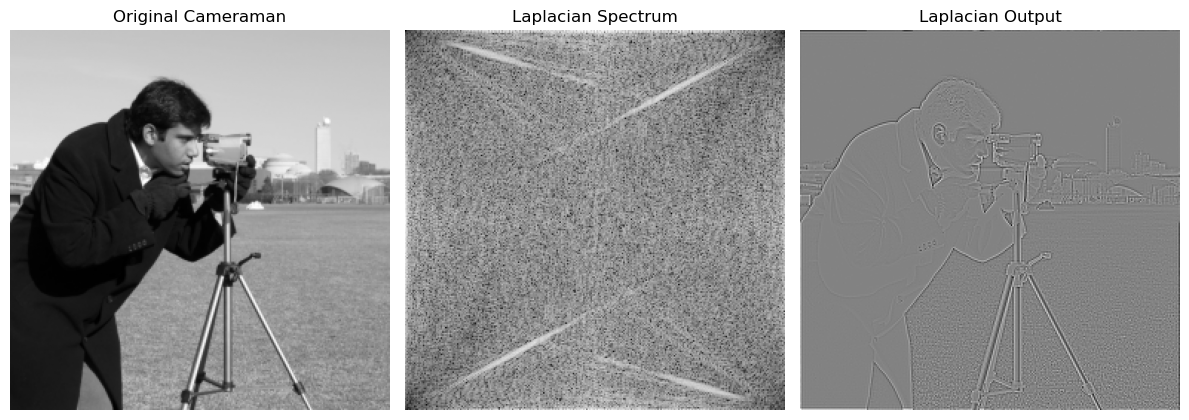

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian Output')
plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

In [12]:
from numpy.fft import fft2, ifft2, ifftshift

def center_embed_kernel(kernel, shape):

    padded = np.zeros(shape)

    kh, kw = kernel.shape
    ph, pw = shape

    cy, cx = ph // 2, pw // 2

    padded[
        cy - kh//2 : cy - kh//2 + kh,
        cx - kw//2 : cx - kw//2 + kw
    ] = kernel

    return fft2(ifftshift(padded))

In [13]:
F = fft2(image)

In [14]:
Hx = center_embed_kernel(sobel_x, image.shape)

Hy = center_embed_kernel(sobel_y, image.shape)

In [15]:
Gx = F * Hx
Gy = F * Hy

In [16]:
sobel_x_image = np.abs(ifft2(Gx))
sobel_y_image = np.abs(ifft2(Gy))

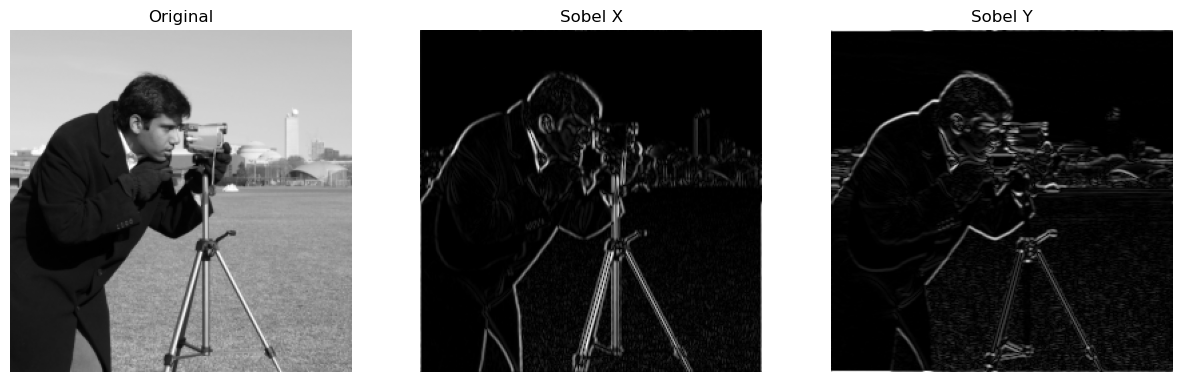

In [19]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sobel_x_image, cmap='gray')
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sobel_y_image, cmap='gray')
plt.title("Sobel Y")
plt.axis("off")

plt.show()